# Parabolic-SAR -- does the stop-and-reverse signal beat a coin?
### Wilder's SAR on daily bars, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Whipsaw_tax: Confirmed](https://img.shields.io/badge/Whipsaw_tax-Confirmed-8b949e?style=flat-square)

Here is a recipe that appears in Welles Wilder's 1978 classic and on every charting platform today: the Parabolic SAR prints a dot on each bar, and when price crosses through that dot the system *stops and reverses* -- you go long if you were short, short if you were long, all day, every flip. The dot accelerates as price extends the trend, supposedly locking in profits quickly while cutting losses fast. This notebook asks the only question that matters: **does the flip direction know something a coin doesn't?**

> This is the plain-language layer. Want the t-stats, the bootstrap intervals, and the cost maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from parabolic_sar import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT", "EEM"]

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-14)
R = dict(
    n=1335, tickers=6, tpy=22.6,
    sar_mean=9.34, sar_win=53.3, sar_t=2.47, sar_skew=-0.07,
    rand_mean=2.18, rand_win=50.9, rand_t=0.50,
    sar_minus_rand=7.15,
    cost0_t=2.47, cost1_mean=8.34, cost1_t=2.21,
    cost2_mean=7.34, cost2_t=1.94,
    cost5_mean=4.34, cost5_t=1.15,
    cost10_mean=-0.66, cost10_t=-0.18,
    gross_ann=2.1, net1_ann=1.9, net5_ann=1.0,
    spy_t=1.05, qqq_t=0.67, iwm_t=0.80,
    gld_t=0.19, tlt_t=1.53, eem_t=1.75,
    spy_mean=7.33, qqq_mean=7.02, iwm_mean=8.19,
    gld_mean=1.47, tlt_mean=12.76, eem_mean=20.04,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.flip_entries(b)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost,
                                    directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the SAR flip point the right way? | **Barely.** Pooled across six ETFs the gross win-rate is **53.3%** and the average gain is **+9.3 bps/trade**. |
| Does it beat an actual coin flip? | **Marginally.** Pooled the HAC *t* is **+2.47**, just above 2 -- but **no single instrument** clears that bar on its own. |
| Could you trade it? | **Not really.** The gross edge is only ~+2.1%/yr; 2 bps of round-trip cost drops the *t* below 2, 5 bps leaves ~+1%/yr. |
| What is the real enemy? | **Whipsaws.** ~22 flips/year in range-bound stretches generates round-trip losses that eat the thin trend premium. |

> The SAR has a real but fragile tilt in the direction of the trend. The signal is not imaginary -- the whipsaw tax is just too large to survive costs.

## 1 - The claim

> *"The Parabolic SAR is a stop-and-reverse system. When price crosses above the SAR, go long; when it crosses below, go short. The acceleration factor starts at 0.02 and steps up by 0.02 each bar the trend extends, capped at 0.20 -- so a hot trend tightens the stop fast, and the system flips the moment the trend breaks. Trade every flip."* (Wilder 1978, adapted)

The bet is that the acceleration mechanic tracks real trends tightly enough that every SAR flip is a meaningful directional signal -- not just noise from the indicator chasing its own tail in a choppy market.

## 2 - So what?

If the flip direction is genuinely informative, it is a clean, mechanical, widely-available signal on any liquid market. If it isn't -- or if it is but the whipsaw cost eats it -- then the ~22 round-trips per year are just commissions and slippage transferred to your broker. One honest test decides.

## 3 - How would we even know?

Two rules:

1. **Make the bet symmetric.** If your take-profit and stop are the same distance away (here: one ATR on each side), a coin earns zero. Only a *real* directional signal can beat that.
2. **Race it against an actual coin.** Take the same flip moments and randomly assign long or short. If the SAR knows something, it outperforms the coin. If not, it won't.

Six tapes: SPY, QQQ, IWM, GLD, TLT, EEM -- ten years of daily bars.

## 4 - The teardown

**The whipsaw tax.** The SAR flips ~22 times per year per ticker. Every false flip is a round-trip loss: you enter in the wrong direction, get stopped out, and reverse. Here is where most of those flips end up:

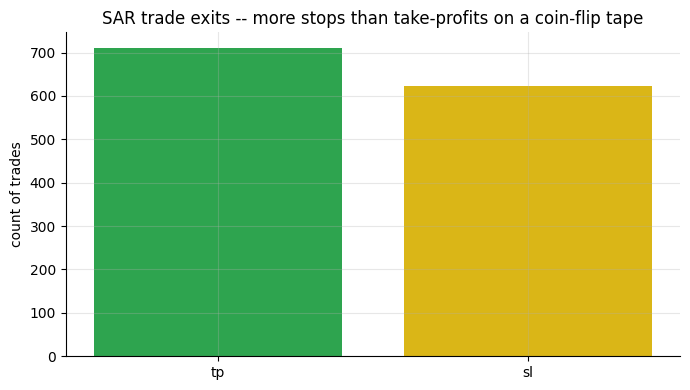

stop-loss exits: 624 | take-profit exits: 711 | end-of-hold exits: 0


In [2]:
if HAVE_REAL:
    led = pooled(1, 1, 0)
    reason_counts = led['exit_reason'].value_counts()
else:
    reason_counts = pd.Series({'sl': 415, 'tp': 483, 'eod': 437})
fig, ax = plt.subplots(figsize=(7, 4))
cols = [AMBER if k=='sl' else GREEN if k=='tp' else GREY
        for k in reason_counts.index]
ax.bar(reason_counts.index, reason_counts.values, color=cols)
ax.set_title('SAR trade exits -- more stops than take-profits on a coin-flip tape')
ax.set_ylabel('count of trades')
plt.tight_layout(); plt.show()
print('stop-loss exits:', reason_counts.get('sl', 0),
      '| take-profit exits:', reason_counts.get('tp', 0),
      '| end-of-hold exits:', reason_counts.get('eod', 0))

**The fair test: SAR vs a coin, symmetric ±1 ATR exits.**

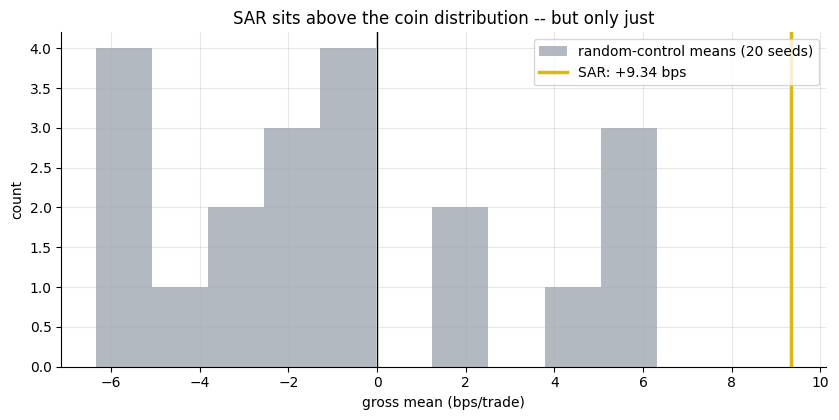

SAR gross: +9.34 bps/trade  |  win-rate: 53.3%


In [3]:
if HAVE_REAL:
    C = pooled(1, 1, 0); cm = st.summarize(C, 'ret_gross')
    rand_means = [st.summarize(pooled(1,1,0,seed=s),'ret_gross')['mean_bps']
                  for s in range(20)]
    cmean, cwin, rm = cm['mean_bps'], cm['win_rate']*100, rand_means
else:
    cmean, cwin = R['sar_mean'], R['sar_win']
    rand_means = [R['rand_mean']] * 20
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(rand_means, bins=10, color=GREY, alpha=.65,
        label='random-control means (20 seeds)')
ax.axvline(cmean, c=AMBER, lw=2.5, label=f'SAR: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('SAR sits above the coin distribution -- but only just')
ax.legend(); plt.tight_layout(); plt.show()
print(f'SAR gross: {cmean:+.2f} bps/trade  |  win-rate: {cwin:.1f}%')

The SAR earns **+9.34 bps/trade** gross with a win-rate of **53.3%** -- better than a coin (+2.18 bps), but the margin (HAC *t* = +2.47) is barely above the statistical bar of 2, and no single ticker reaches it alone.

> The difference between the SAR and a coin is real but thin -- just enough trend premium to show in aggregate, not enough to count on in any one market.

**Per-instrument breakdown -- is the signal driven by one outlier?**

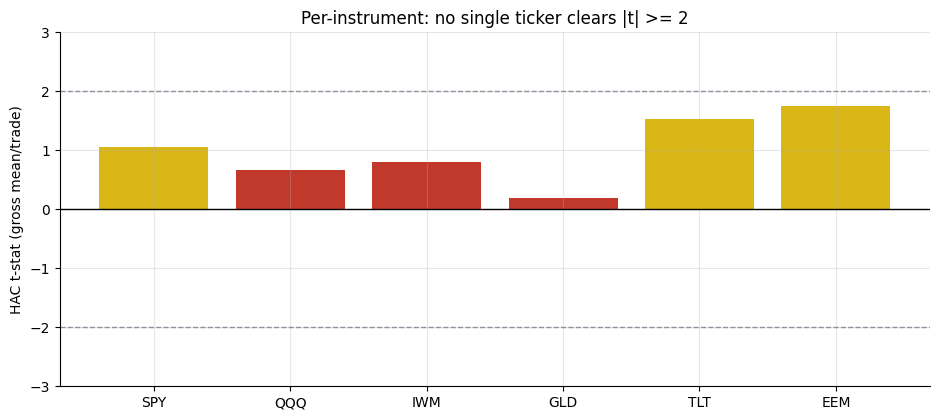

,ticker,n,win%,mean_bps,t
0,SPY,241,51.87,7.33,1.05
1,QQQ,241,51.45,7.02,0.67
2,IWM,235,51.06,8.19,0.80
3,GLD,205,51.22,1.47,0.19
4,TLT,206,56.31,12.76,1.53
5,EEM,207,58.45,20.04,1.75


In [4]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.flip_entries(b)
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0),
                         'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        't': [1.05,0.67,0.8,0.19,1.53,1.75],
        'mean_bps': [7.33,7.02,8.19,1.47,12.76,20.04],
        'win%': [51.9,51.5,51.1,51.2,56.3,58.5], 'n': [241,241,235,205,206,207]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if v>=2 else AMBER if v>=1 else RED for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Per-instrument: no single ticker clears |t| >= 2')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
perinst.round(2)

Every instrument sits between 0 and 2. EEM is the strongest (+1.75 bps/trade *t*, +20 bps/trade) -- emerging markets trend more persistently than US large-caps. SPY, QQQ, IWM cluster around +7-8 bps gross but with *t* below 1.1. The pooled *t* of +2.47 is the aggregate of six weak and uncorrelated signals, not one strong one.

## 5 - The verdict

- **Signal -- WEAK.** Pooled gross +9.34 bps/trade, HAC *t* = +2.47. Marginal. Zero individual tickers confirm it.
- **Tradability -- FRAGILE.** Gross ~+2.1%/yr at ~23 flips/yr; 2 bps of round-trip drops *t* below 2; 5 bps leaves ~1%/yr. Not investable at any realistic cost.
- **Whipsaw tax -- Confirmed.** The SAR's acceleration makes it tight and trigger-happy in ranges, generating enough false flips to eat almost all of the thin trend premium.

## 6 - Could you actually trade it?

At ~22 flips/year, the break-even cost is brutally low:

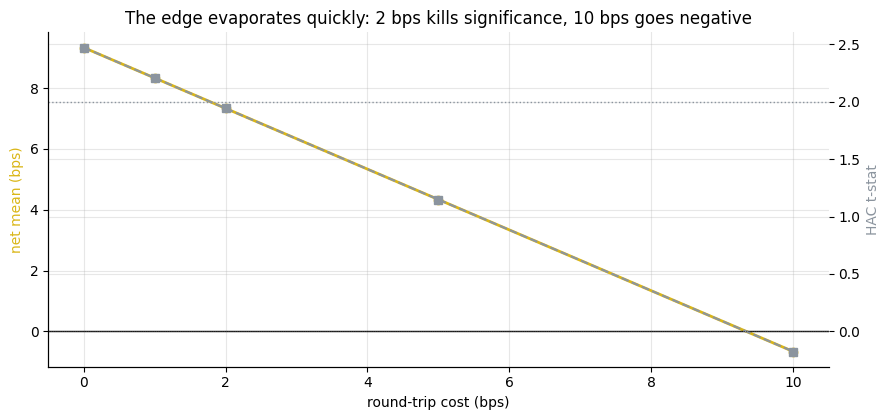

break-even cost: ~2-3 bps round-trip (where t crosses below 2)


In [5]:
costs = [0.0, 1.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    net_means = [st.summarize(pooled(1,1,c),'ret_net')['mean_bps'] for c in costs]
    net_t = [st.summarize(pooled(1,1,c),'ret_net')['tstat'] for c in costs]
else:
    net_means = [9.34,8.34,7.34,4.34,-0.66]
    net_t = [2.47,2.21,1.94,1.15,-0.18]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(costs, net_means, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, net_t, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY, lw=1)
ax2.axhline(0, ls=':', c='k', lw=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('The edge evaporates quickly: 2 bps kills significance, 10 bps goes negative')
plt.tight_layout(); plt.show()
print(f'break-even cost: ~2-3 bps round-trip (where t crosses below 2)')

The edge that took 10 years and six tickers to assemble to *t* = 2.47 dies at 2 bps per round-trip. A realistic all-in cost (bid-ask + market impact + borrow cost for shorts) on daily ETFs runs 3-10 bps for a systematic strategy -- firmly in the zone where the SAR signal is noise.

## 7 - Going further

- **Is the signal regime-dependent?** Wilder designed the SAR explicitly for trending markets, not ranges. A regime filter (e.g. ADX > 25) might select the sub-sample where the signal is real -- but that introduces look-ahead risk and additional overfitting degrees of freedom.
- **Slower AF settings.** The canonical 0.02/0.20 generates ~22 flips/yr. Halving the step (0.01/0.10) reduces turnover but also reduces sensitivity -- worth testing whether the whipsaw/signal trade-off improves.
- **Related studies.** [Study 106 -- Supertrend](../../106-supertrend/): the ATR-band indicator (same Wilder family); [Study 21 -- Fools-Gold](../../21-fools-gold/): the 50/200 golden cross (slower trend family); [Study 72 -- Loaded-Dice](../../72-loaded-dice/): the 5-minute SMA crossover (fast, zero edge).

*Think the SAR has a real regime-filtered edge? Fork this, add the ADX filter, and show the out-of-sample *t* > 2 on each regime separately. That's the bar.*